# SAM Poker Card Segmentation
Genera máscaras de segmentación automáticamente desde bounding boxes usando `facebook/sam-vit-base`.
El output es un COCO JSON con polígonos de segmentación listo para importar en Roboflow.

DATASET: https://www.kaggle.com/datasets/jaypradipshah/the-complete-playing-card-dataset?resource=download

## 1. Montar Drive y descomprimir archive.zip

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Ajusta esta ruta a donde tengas archive.zip en tu Drive
ZIP_PATH = '/content/drive/MyDrive/archive.zip'
EXTRACT_DIR = '/content/archive'

os.makedirs(EXTRACT_DIR, exist_ok=True)
!unzip -q "{ZIP_PATH}" -d "{EXTRACT_DIR}"
print('Contenido extraído:')
!ls "{EXTRACT_DIR}"

Contenido extraído:
annotation.json  Annotations  Images  YOLO_Annotations


In [3]:
import glob

xml_files = glob.glob(f'{EXTRACT_DIR}/**/*.xml', recursive=True)
xml_files = list(set(f for f in xml_files if 'Zone.Identifier' not in f))

jpg_files = glob.glob(f'{EXTRACT_DIR}/**/*.jpg', recursive=True)
jpg_files = list(set(f for f in jpg_files if 'Zone.Identifier' not in f))

IMAGES_DIR = os.path.dirname(jpg_files[0]) if jpg_files else ''

print(f'XMLs encontrados   : {len(xml_files)}')
print(f'Imágenes encontradas: {len(jpg_files)}')
print(f'Dir imágenes       : {IMAGES_DIR}')

XMLs encontrados   : 2757
Imágenes encontradas: 2757
Dir imágenes       : /content/archive/Images/Images


## 2. Instalar dependencias

In [4]:
!pip install -q transformers accelerate Pillow opencv-python-headless tqdm

## 3. Cargar SAM desde Hugging Face

In [5]:
import torch
from transformers import SamProcessor, SamModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando: {device}')

sam_id = 'facebook/sam-vit-base'
sam_processor = SamProcessor.from_pretrained(sam_id)
sam_model = SamModel.from_pretrained(sam_id).to(device)
sam_model.eval()
print('SAM cargado correctamente')

Usando: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SAM cargado correctamente


## 3b. (Opcional) Cargar Grounding DINO — no se usa en el pipeline actual

> Celda desactivada. El pipeline usa SAM con point prompt directamente.
> Si quieres reactivar GDINO en el futuro, descomenta y ejecuta esta celda.

In [6]:
# from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
# gd_id = 'IDEA-Research/grounding-dino-tiny'
# gd_processor = AutoProcessor.from_pretrained(gd_id)
# gd_model = AutoModelForZeroShotObjectDetection.from_pretrained(gd_id).to(device)
# gd_model.eval()
print('(GDINO desactivado — no necesario con SAM point prompt)')

(GDINO desactivado — no necesario con SAM point prompt)


## 4. Mapeo de clases: formato archive → formato Roboflow

In [7]:
SUIT_MAP = {'S': 'Spades', 'C': 'Clubs', 'D': 'Diamonds', 'H': 'Hearts'}

def archive_class_to_roboflow(name: str) -> str:
    """Convierte 'AS' -> 'A Spades', '10C' -> '10 Clubs', etc."""
    name = name.strip()
    if name == 'JOKER':
        return 'Joker'
    suit_char = name[-1]
    value = name[:-1]
    suit = SUIT_MAP.get(suit_char, suit_char)
    return f'{value} {suit}'

# Verificar
tests = ['AS', 'AC', 'AD', 'AH', '10C', 'JS', 'QH', 'KD', 'JOKER']
for t in tests:
    print(f'  {t:6s} -> {archive_class_to_roboflow(t)}')

  AS     -> A Spades
  AC     -> A Clubs
  AD     -> A Diamonds
  AH     -> A Hearts
  10C    -> 10 Clubs
  JS     -> J Spades
  QH     -> Q Hearts
  KD     -> K Diamonds
  JOKER  -> Joker


## 5. Parsear anotaciones XML (Pascal VOC)

In [8]:
import xml.etree.ElementTree as ET

def parse_xml(xml_path: str) -> dict:
    tree = ET.parse(xml_path)
    root = tree.getroot()
    size = root.find('size')
    data = {
        'filename': root.find('filename').text,
        'width':  int(size.find('width').text),
        'height': int(size.find('height').text),
        'objects': []
    }
    for obj in root.findall('object'):
        bb = obj.find('bndbox')
        data['objects'].append({
            'name': obj.find('name').text,
            'xmin': int(bb.find('xmin').text),
            'ymin': int(bb.find('ymin').text),
            'xmax': int(bb.find('xmax').text),
            'ymax': int(bb.find('ymax').text),
        })
    return data

# Test
print(parse_xml(xml_files[0]))

{'filename': '10H49.jpg', 'width': 4608, 'height': 3456, 'objects': [{'name': '10H', 'xmin': 1272, 'ymin': 1842, 'xmax': 1687, 'ymax': 2113}]}


## 6. Pipeline: SAM point prompt → máscara → polígono COCO

El XML tiene la bbox del indicador de esquina de la carta.  
Se usa el **centro de esa bbox como punto positivo para SAM** — SAM segmenta el objeto completo en ese punto (la carta entera).  
No se necesita GDINO ni expandir bbox manualmente.

In [9]:
import numpy as np
import cv2
from PIL import Image

@torch.no_grad()
def bbox_to_polygon(image_pil: Image.Image, hint_bbox: list) -> tuple:
    """
    Usa el centro del hint_bbox como punto positivo para SAM.
    Elige la máscara de MAYOR ÁREA entre las 3 que genera SAM
    (SAM devuelve sub-parte / parte / todo — queremos 'todo' = la carta completa).
    Devuelve (polygons, bbox_final).
    """
    hx1, hy1, hx2, hy2 = hint_bbox
    cx = (hx1 + hx2) / 2
    cy = (hy1 + hy2) / 2

    inputs = sam_processor(
        images=image_pil,
        input_points=[[[cx, cy]]],
        input_labels=[[1]],
        return_tensors='pt'
    ).to(device)
    outputs = sam_model(**inputs)

    masks = sam_processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs['original_sizes'].cpu(),
        inputs['reshaped_input_sizes'].cpu()
    )[0]  # shape: [1, 3, H, W]

    # Elegir la máscara con MAYOR ÁREA (no mayor IoU)
    # SAM genera: [sub-parte, parte, todo] — queremos la más grande
    areas = [masks[0, i].sum().item() for i in range(masks.shape[1])]
    best_idx = int(np.argmax(areas))
    mask = masks[0, best_idx].numpy().astype(np.uint8)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return [], hint_bbox

    contour = max(contours, key=cv2.contourArea)
    epsilon = 0.002 * cv2.arcLength(contour, True)
    approx  = cv2.approxPolyDP(contour, epsilon, True)

    if len(approx) < 3:
        return [], hint_bbox

    pts = approx.reshape(-1, 2)
    x1, y1 = pts[:, 0].min(), pts[:, 1].min()
    x2, y2 = pts[:, 0].max(), pts[:, 1].max()

    return [approx.flatten().tolist()], [int(x1), int(y1), int(x2), int(y2)]

print('bbox_to_polygon — selección por área máxima definida')

bbox_to_polygon — selección por área máxima definida


Imagen    : 10H49.jpg
Clase     : 10H → 10 Hearts
BBox XML  : [1272, 1842, 1687, 2113]
BBox SAM  : [1181, 1204, 3353, 2593]
Puntos    : 16


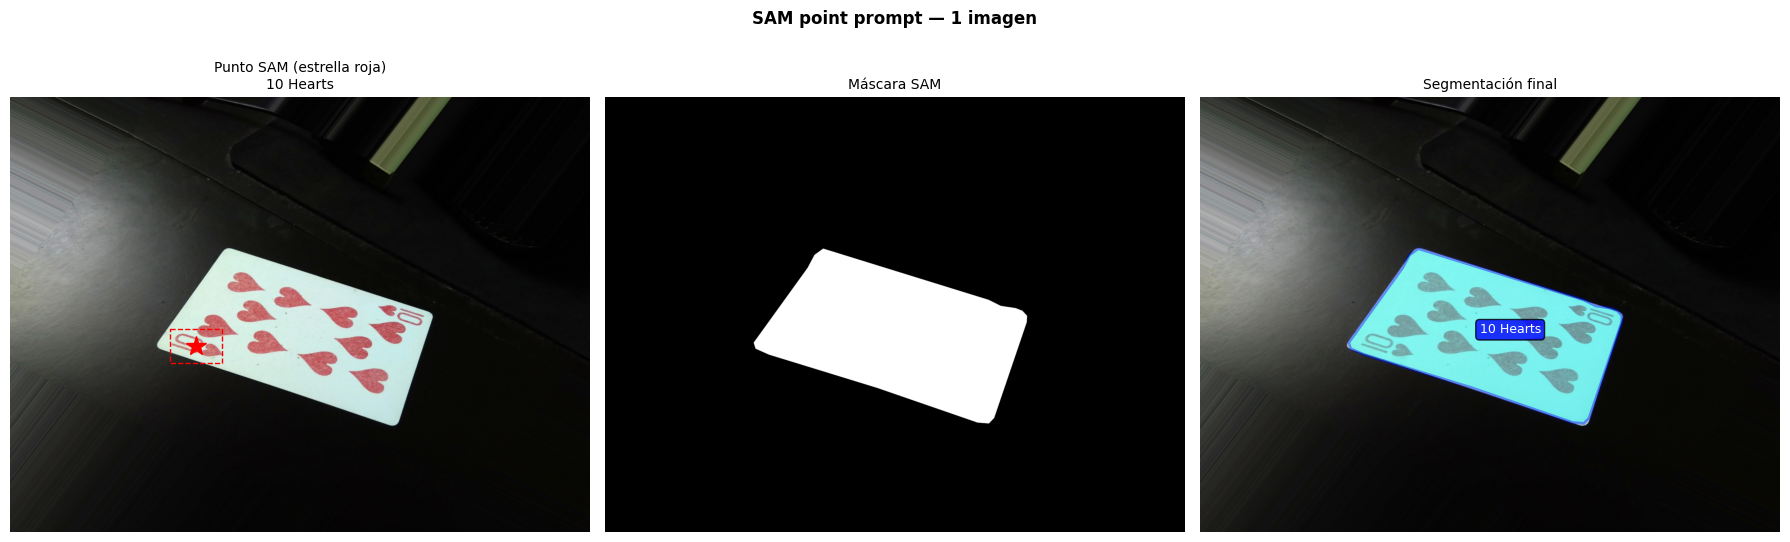

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon as MplPolygon

test_xml = xml_files[0]
test_ann = parse_xml(test_xml)

candidates = glob.glob(f'{EXTRACT_DIR}/**/{test_ann["filename"]}', recursive=True)
candidates = [c for c in candidates if 'Zone.Identifier' not in c]
assert candidates, f'No se encontró: {test_ann["filename"]}'

test_img_pil = Image.open(candidates[0]).convert('RGB')
test_img_np  = np.array(test_img_pil)

obj       = test_ann['objects'][0]
hint_bbox = [obj['xmin'], obj['ymin'], obj['xmax'], obj['ymax']]
label     = archive_class_to_roboflow(obj['name'])

print(f'Imagen    : {test_ann["filename"]}')
print(f'Clase     : {obj["name"]} → {label}')
print(f'BBox XML  : {hint_bbox}')

polygons, seg_bbox = bbox_to_polygon(test_img_pil, hint_bbox)
print(f'BBox SAM  : {seg_bbox}')
print(f'Puntos    : {len(polygons[0]) // 2 if polygons else 0}')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Imagen + punto de prompt (centro del hint_bbox)
cx = (hint_bbox[0] + hint_bbox[2]) / 2
cy = (hint_bbox[1] + hint_bbox[3]) / 2
axes[0].imshow(test_img_np)
axes[0].plot(cx, cy, 'r*', markersize=15)
axes[0].add_patch(patches.Rectangle(
    (hint_bbox[0], hint_bbox[1]),
    hint_bbox[2]-hint_bbox[0], hint_bbox[3]-hint_bbox[1],
    linewidth=1, edgecolor='red', facecolor='none', linestyle='--'
))
axes[0].set_title(f'Punto SAM (estrella roja)\n{label}', fontsize=10)
axes[0].axis('off')

# 2) Máscara binaria SAM
if polygons:
    mask_vis = np.zeros(test_img_np.shape[:2], dtype=np.uint8)
    pts = np.array(polygons[0]).reshape(-1, 1, 2).astype(np.int32)
    cv2.fillPoly(mask_vis, [pts], 255)
    axes[1].imshow(mask_vis, cmap='gray')
axes[1].set_title('Máscara SAM' if polygons else 'Sin máscara', fontsize=10)
axes[1].axis('off')

# 3) Overlay final
axes[2].imshow(test_img_np)
if polygons:
    poly_pts = np.array(polygons[0]).reshape(-1, 2)
    axes[2].add_patch(MplPolygon(
        poly_pts, closed=True, fill=True,
        facecolor='cyan', alpha=0.4, edgecolor='blue', linewidth=2
    ))
    pcx, pcy = poly_pts[:, 0].mean(), poly_pts[:, 1].mean()
    axes[2].text(pcx, pcy, label, color='white', fontsize=9, ha='center',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='blue', alpha=0.8))
axes[2].set_title('Segmentación final', fontsize=10)
axes[2].axis('off')

plt.suptitle('SAM point prompt — 1 imagen', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/test_sam_point.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
from tqdm import tqdm
import json

OUTPUT_JSON = '/content/drive/MyDrive/poker_segmentation_coco.json'

all_classes_archive = [
    'AS','AC','AD','AH','2S','2C','2D','2H','3S','3C','3D','3H',
    '4S','4C','4D','4H','5S','5C','5D','5H','6S','6C','6D','6H',
    '7S','7C','7D','7H','8S','8C','8D','8H','9S','9C','9D','9H',
    '10S','10C','10D','10H','JS','JC','JD','JH','QS','QC','QD','QH',
    'KS','KC','KD','KH','JOKER'
]
categories = [
    {'id': i+1, 'name': archive_class_to_roboflow(c), 'supercategory': 'card'}
    for i, c in enumerate(all_classes_archive)
]
cat_name_to_id = {c['name']: c['id'] for c in categories}

coco_output = {
    'info': {'description': 'Poker cards segmentation — SAM point prompt'},
    'categories': categories,
    'images': [],
    'annotations': []
}

image_id = 0
ann_id   = 0
errors   = []

for xml_path in tqdm(xml_files, desc='Procesando imágenes'):
    try:
        ann_data     = parse_xml(xml_path)
        img_filename = ann_data['filename']

        candidates = glob.glob(f'{EXTRACT_DIR}/**/{img_filename}', recursive=True)
        candidates  = [c for c in candidates if 'Zone.Identifier' not in c]
        if not candidates:
            errors.append(f'No encontrada: {img_filename}')
            continue
        img_path = candidates[0]

        image_pil = Image.open(img_path).convert('RGB')
        W, H = image_pil.size

        image_id += 1
        coco_output['images'].append({
            'id': image_id, 'file_name': img_filename, 'width': W, 'height': H
        })

        for obj in ann_data['objects']:
            hint_bbox = [obj['xmin'], obj['ymin'], obj['xmax'], obj['ymax']]
            polygons, seg_bbox = bbox_to_polygon(image_pil, hint_bbox)

            if not polygons:
                errors.append(f'Sin máscara: {img_filename} cls={obj["name"]}')
                continue

            bw = seg_bbox[2] - seg_bbox[0]
            bh = seg_bbox[3] - seg_bbox[1]
            roboflow_name = archive_class_to_roboflow(obj['name'])
            cat_id = cat_name_to_id[roboflow_name]

            ann_id += 1
            coco_output['annotations'].append({
                'id': ann_id,
                'image_id': image_id,
                'category_id': cat_id,
                'segmentation': polygons,
                'bbox': [seg_bbox[0], seg_bbox[1], bw, bh],
                'area': bw * bh,
                'iscrowd': 0
            })

    except Exception as e:
        errors.append(f'Error en {xml_path}: {e}')

print(f'\nImágenes procesadas : {image_id}')
print(f'Anotaciones generadas: {ann_id}')
print(f'Errores              : {len(errors)}')

with open(OUTPUT_JSON, 'w') as f:
    json.dump(coco_output, f)
print(f'Guardado en: {OUTPUT_JSON}')

Procesando imágenes: 100%|██████████| 2757/2757 [21:18<00:00,  2.16it/s]


Imágenes procesadas : 2757
Anotaciones generadas: 2758
Errores              : 0
Guardado en: /content/drive/MyDrive/poker_segmentation_coco.json


## 8. Visualizar una muestra para verificar

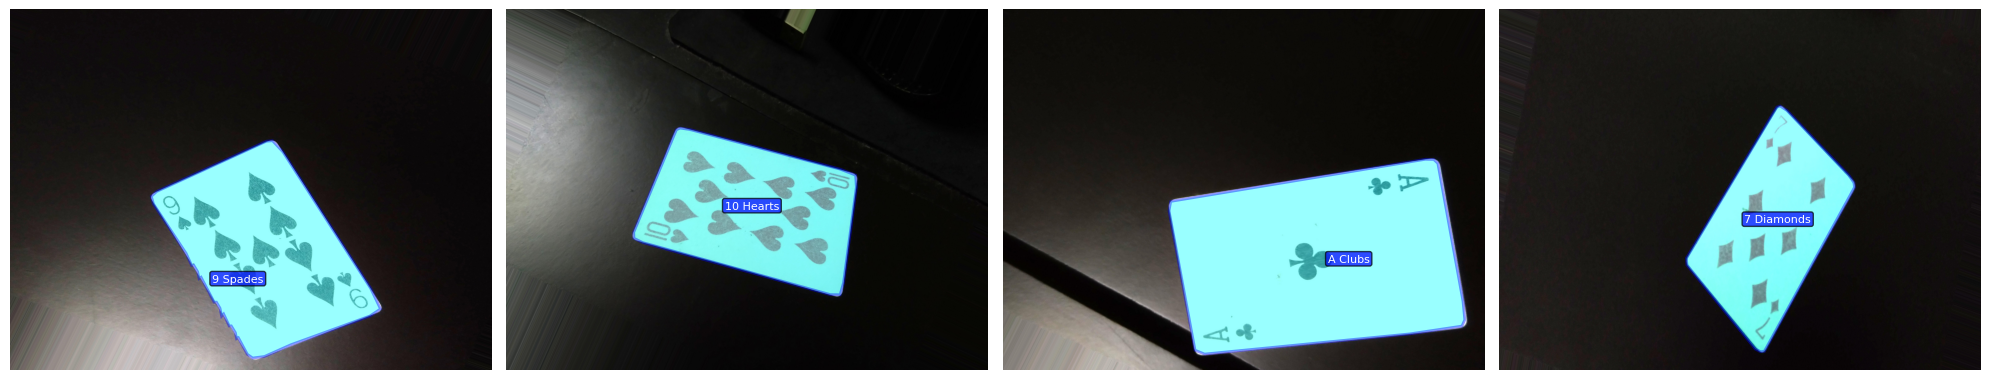

Guardado: /content/sample_segmentation.png


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import random

def show_sample(coco_data, images_dir, n=4):
    img_ids = random.sample([img['id'] for img in coco_data['images']], n)
    cat_id_to_name = {c['id']: c['name'] for c in coco_data['categories']}
    ann_by_img = {}
    for ann in coco_data['annotations']:
        ann_by_img.setdefault(ann['image_id'], []).append(ann)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    for ax, img_id in zip(axes, img_ids):
        img_info = next(i for i in coco_data['images'] if i['id'] == img_id)

        # Buscar imagen
        candidates = glob.glob(f'{EXTRACT_DIR}/**/{img_info["file_name"]}', recursive=True)
        candidates = [c for c in candidates if 'Zone.Identifier' not in c]
        if not candidates:
            continue
        img = np.array(Image.open(candidates[0]).convert('RGB'))

        ax.imshow(img)
        ax.axis('off')

        for ann in ann_by_img.get(img_id, []):
            if ann['segmentation']:
                pts = np.array(ann['segmentation'][0]).reshape(-1, 2)
                poly = MplPolygon(pts, closed=True, fill=True,
                                  facecolor='cyan', alpha=0.4, edgecolor='blue', lw=2)
                ax.add_patch(poly)
                cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
                ax.text(cx, cy, cat_id_to_name[ann['category_id']],
                        color='white', fontsize=8, ha='center',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='blue', alpha=0.7))
    plt.tight_layout()
    plt.savefig('/content/sample_segmentation.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Guardado: /content/sample_segmentation.png')

show_sample(coco_output, IMAGES_DIR)

## 9. Preparar ZIP para subir a Roboflow

Roboflow acepta un ZIP con:
```
dataset/
  _annotations.coco.json
  imagen1.jpg
  imagen2.jpg
  ...
```

In [13]:
import shutil
import zipfile

ROBOFLOW_DIR = '/content/roboflow_upload'
os.makedirs(ROBOFLOW_DIR, exist_ok=True)

# Copiar JSON con el nombre que espera Roboflow
shutil.copy(OUTPUT_JSON, f'{ROBOFLOW_DIR}/_annotations.coco.json')

# Copiar imágenes que tienen anotaciones
img_ids_with_anns = set(a['image_id'] for a in coco_output['annotations'])
imgs_to_copy = [i for i in coco_output['images'] if i['id'] in img_ids_with_anns]

print(f'Copiando {len(imgs_to_copy)} imágenes...')
not_found = 0
for img_info in tqdm(imgs_to_copy):
    candidates = glob.glob(f'{EXTRACT_DIR}/**/{img_info["file_name"]}', recursive=True)
    candidates = [c for c in candidates if 'Zone.Identifier' not in c]
    if candidates:
        shutil.copy(candidates[0], os.path.join(ROBOFLOW_DIR, img_info['file_name']))
    else:
        not_found += 1

print(f'Imágenes no encontradas: {not_found}')

# Crear ZIP
ZIP_OUTPUT = '/content/drive/MyDrive/poker_roboflow_upload.zip'
with zipfile.ZipFile(ZIP_OUTPUT, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(ROBOFLOW_DIR):
        zf.write(os.path.join(ROBOFLOW_DIR, fname), fname)

print(f'\nZIP listo para Roboflow: {ZIP_OUTPUT}')
print('Ve a Roboflow → New Dataset → Upload → COCO Segmentation')

Copiando 2757 imágenes...


100%|██████████| 2757/2757 [00:15<00:00, 183.74it/s]


Imágenes no encontradas: 0

ZIP listo para Roboflow: /content/drive/MyDrive/poker_roboflow_upload.zip
Ve a Roboflow → New Dataset → Upload → COCO Segmentation


In [24]:
import json

with open('/content/drive/MyDrive/poker_segmentation_coco.json') as f:
    coco = json.load(f)

coco['licenses'] = [{'id': 1, 'name': 'Unknown', 'url': ''}]
for img in coco['images']:
    img['license'] = 1

with open('/content/drive/MyDrive/poker_segmentation_coco.json', 'w') as f:
    json.dump(coco, f)

# Copiar al directorio de upload y volver a intentar
import shutil, os
shutil.copy('/content/drive/MyDrive/poker_segmentation_coco.json',
            '/content/blackjackvai/_annotations.coco.json')
print('Listo')

Listo


## Instrucciones para subir a Roboflow

1. Descarga `poker_roboflow_upload.zip` de tu Drive
2. En [Roboflow](https://roboflow.com) → **New Project** → tipo **Instance Segmentation**
3. **Upload** → arrastra el ZIP
4. Selecciona formato **COCO Segmentation**
5. Roboflow detectará automáticamente las 53 clases con sus polígonos
6. Puedes combinar este dataset con tus anotaciones SAM manuales usando **Merge Datasets**

In [14]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 72.7 MB/s eta 0:00:00


In [25]:
from roboflow import Roboflow

rf = Roboflow(api_key="sfoh8lecp4kiqvEU7De6")
ws = rf.workspace("javiers-workspace-q8mnr")
ws.upload_dataset(
      dataset_path="/content/blackjackvai",
      project_name="blackjackvai",
      num_workers=4,
      dataset_format="coco",
      project_license="MIT",
      project_type="instance-segmentation"
  )

loading Roboflow workspace...
loading Roboflow project...


100%|██████████| 2757/2757 [00:00<00:00, 18038.74it/s]


Uploading to existing project javiers-workspace-q8mnr/blackjackvai
[UPLOADED] /content/blackjackvai/10C2.jpg (GEbWI90fVpiJdgWiiVc6) [3.9s] / annotations = OK [0.4s]
[UPLOADED] /content/blackjackvai/10C1.jpg (YRjPPmuZw6LLtdcbnwbu) [6.0s] / annotations = OK [0.3s]
[UPLOADED] /content/blackjackvai/10C3.jpg (JD5q9nXQQYXqS9qlIMHI) [6.2s] / annotations = OK [0.5s]
[UPLOADED] /content/blackjackvai/10C0.jpg (DJbZ89vODmyQuOsXxCdh) [6.5s] / annotations = OK [0.3s]
[UPLOADED] /content/blackjackvai/10C4.jpg (y2AyTs1zAk6GbdVj37JN) [2.9s] / annotations = OK [0.4s]
[UPLOADED] /content/blackjackvai/10C7.jpg (hplu2tUgwhcpMTrGaWfi) [2.5s] / annotations = OK [0.3s]
[UPLOADED] /content/blackjackvai/10C6.jpg (KMjABT5oHuBJLOteJNv7) [2.9s] / annotations = OK [0.3s]
[UPLOADED] /content/blackjackvai/10C8.jpg (m2mrKPpW8eMQrxJtVahG) [3.1s] / annotations = OK [0.4s]
[UPLOADED] /content/blackjackvai/10C5.jpg (jJOYEQ8pbIPU1gx6HI6Y) [4.4s] / annotations = OK [0.3s]
[UPLOADED] /content/blackjackvai/10C10.jpg (iaSIfSP